In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def f(x):
    return x**3 - x - 2

a = 1
b = 2

tolerance = 0.000001
max_iterations = 100

In [4]:
iterations = []
roots = []
function_values = []
absolute_errors = []
relative_errors = []

previous_root = None

for i in range(1, max_iterations + 1):

    fa = f(a)
    fb = f(b)

    # False Position formula
    c = (a * fb - b * fa) / (fb - fa)
    fc = f(c)

    # Error calculation
    if previous_root is None:
        abs_error = np.nan
        rel_error = np.nan
    else:
        abs_error = abs(c - previous_root)
        rel_error = abs_error / abs(c)

    iterations.append(i)
    roots.append(c)
    function_values.append(fc)
    absolute_errors.append(abs_error)
    relative_errors.append(rel_error)

    # Check convergence
    if previous_root is not None and abs_error < tolerance:
        break

    # Update interval
    if fa * fc < 0:
        b = c
    else:
        a = c

    previous_root = c

In [5]:
result = pd.DataFrame({
    "Iteration": iterations,
    "Root": roots,
    "f(c)": function_values,
    "Absolute Error": absolute_errors,
    "Relative Error": relative_errors
})

print(result.to_string(index=False))

print("\nApproximate Root =", roots[-1])
print("Number of Iterations =", len(iterations))

 Iteration     Root      f(c)  Absolute Error  Relative Error
         1 1.333333 -0.962963             NaN             NaN
         2 1.462687 -0.333339    1.293532e-01    8.843537e-02
         3 1.504019 -0.101818    4.133244e-02    2.748133e-02
         4 1.516331 -0.029895    1.231156e-02    8.119312e-03
         5 1.519919 -0.008675    3.587985e-03    2.360643e-03
         6 1.520957 -0.002509    1.038931e-03    6.830772e-04
         7 1.521258 -0.000725    3.002678e-04    1.973812e-04
         8 1.521344 -0.000209    8.673511e-05    5.701214e-05
         9 1.521370 -0.000060    2.505031e-05    1.646563e-05
        10 1.521377 -0.000017    7.234550e-06    4.755265e-06
        11 1.521379 -0.000005    2.089317e-06    1.373305e-06
        12 1.521379 -0.000001    6.033863e-07    3.966047e-07

Approximate Root = 1.5213794617901568
Number of Iterations = 12


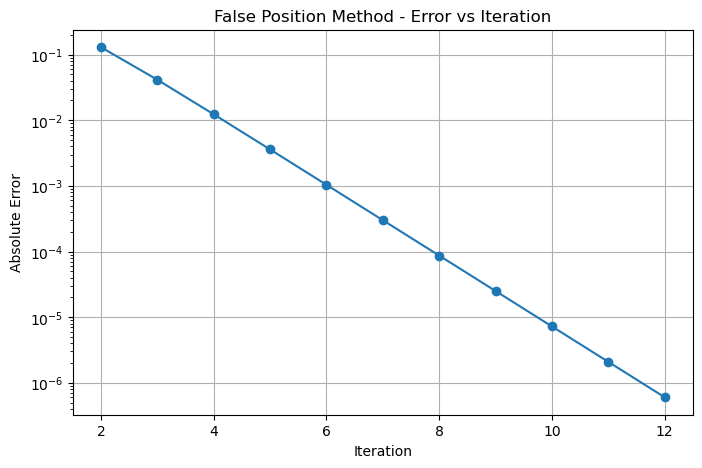

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    iterations[1:],
    absolute_errors[1:],
    marker='o'
)

plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Absolute Error")
plt.title("False Position Method - Error vs Iteration")
plt.grid(True)

plt.show()

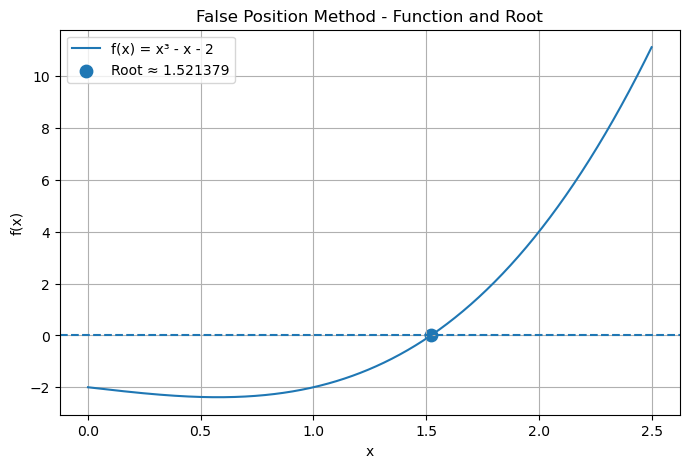

In [7]:
x = np.linspace(0, 2.5, 500)
y = f(x)

root = roots[-1]

plt.figure(figsize=(8, 5))

plt.plot(x, y, label="f(x) = x³ - x - 2")
plt.axhline(0, linestyle="--")

plt.scatter(
    root,
    f(root),
    s=80,
    label=f"Root ≈ {root:.6f}"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("False Position Method - Function and Root")
plt.legend()
plt.grid(True)

plt.show()